# Exploratory Data Analysis - Feature selection via Lasso Ridge Regression

### Objectives
- Find the minimal set of features to accurately predict PCOS using our dataset
- Find the most strong predicting low-cost clinical features (BMI, cycle, symptoms, blood pressure)
- Use mutual_info_classifier to get scores of all features

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['pcos_y_n'].value_counts()}")
df.head()

Dataset shape: (541, 44)
Target distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64


,sl_no,patient_file_no,pcos_y_n,age_yrs,weight_kg,heightcm,bmi,blood_group,pulse_ratebpm,rr_breaths_min,...,pimples_y_n,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm
0,1.0,1.0,0,28.0,44.6,152.0,19.304017,15.0,78.0,22.0,...,0,1,0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,2.0,0,36.0,65.0,161.5,24.921163,15.0,74.0,20.0,...,0,0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,3.0,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,...,1,1,0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,4.0,0,37.0,65.0,148.0,29.674945,13.0,72.0,20.0,...,0,0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,5.0,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,...,0,0,0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


## 1. Mutual Information Feature Scoring

Total features for selection: 41
Mutual Information Scores (all features):
            Feature  MI_Score
      follicle_no_r  0.268131
      follicle_no_l  0.207116
 skin_darkening_y_n  0.090054
    hair_growth_y_n  0.083343
           amhng_ml  0.075631
    weight_gain_y_n  0.074841
          cycle_r_i  0.071932
           prlng_ml  0.065845
             fsh_lh  0.064276
      fast_food_y_n  0.061040
   cycle_lengthdays  0.056107
    avg_f_size_l_mm  0.048178
        pimples_y_n  0.045864
          tsh_miu_l  0.036751
      pulse_ratebpm  0.030356
           prgng_ml  0.029973
      hair_loss_y_n  0.027908
          weight_kg  0.027656
     endometrium_mm  0.027286
            hipinch  0.026815
         fsh_miu_ml  0.026295
          waistinch  0.025131
    waist_hip_ratio  0.024286
          lh_miu_ml  0.023859
marraige_status_yrs  0.018505
       vit_d3_ng_ml  0.017925
  i_beta_hcg_miu_ml  0.017910
                bmi  0.016563
   no_of_aborptions  0.010692
       pregnant_y_n  0.00

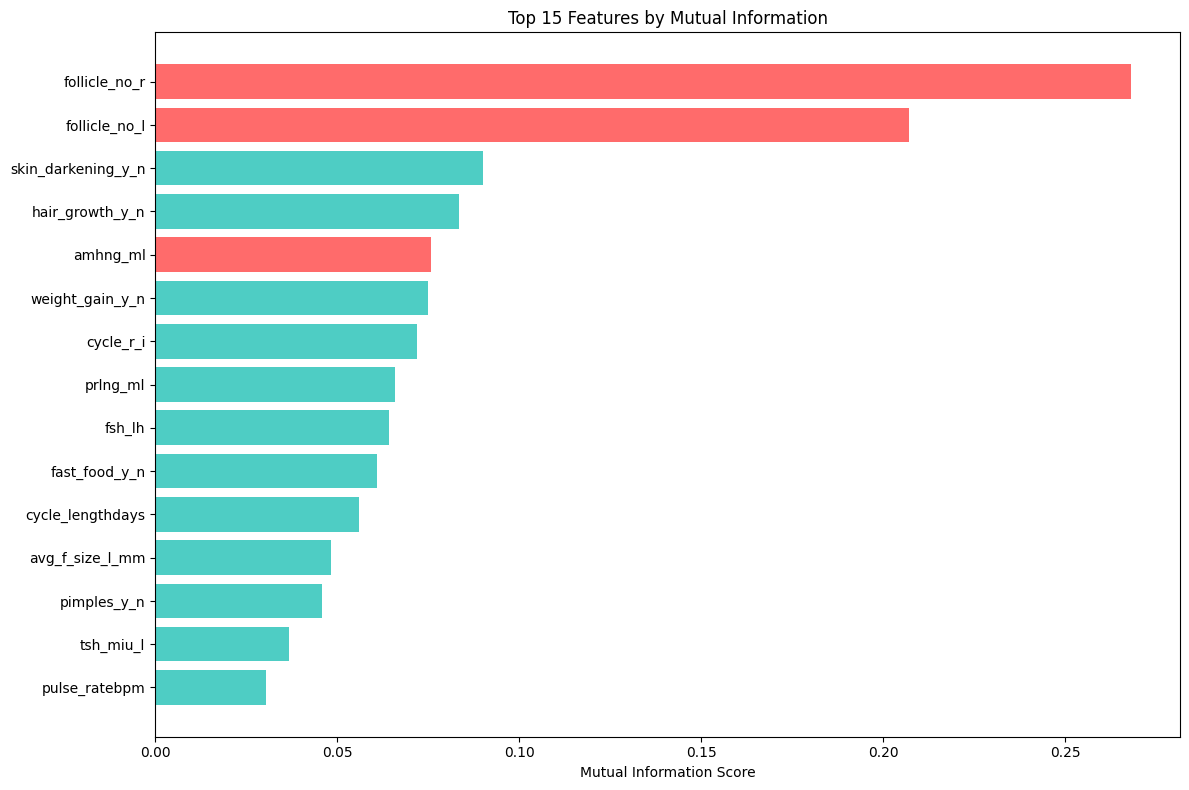

In [31]:
# Prepare data for feature selection
numerical_cols = ['age_yrs', 'weight_kg', 'heightcm', 'bmi', 'pulse_ratebpm', 'rr_breaths_min',
                  'hbg_dl', 'cycle_lengthdays', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh',
                  'hipinch', 'waistinch', 'waist_hip_ratio', 'tsh_miu_l', 'amhng_ml',
                  'prlng_ml', 'vit_d3_ng_ml', 'prgng_ml', 'rbsmg_dl', 'bp_systolic_mmhg',
                  'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r',
                  'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm',
                  'i_beta_hcg_miu_ml', 'ii_beta_hcg_miu_ml',
                  'no_of_aborptions', 'marraige_status_yrs', 'blood_group']

binary_cols = ['cycle_r_i', 'pregnant_y_n', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
               'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n']

all_features = numerical_cols + binary_cols
print(f"Total features for selection: {len(all_features)}")

# Prepare X and y
X = df[all_features].fillna(df[all_features].median(numeric_only=True))
y = df['pcos_y_n']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Mutual Information Scores (all features):")
print("=" * 60)
print(mi_df.to_string(index=False))

# Visualize top features by mutual information
fig, ax = plt.subplots(figsize=(12, 8))
top_mi = mi_df.head(15)
colors = ['#FF6B6B' if 'follicle' in f.lower() or 'amh' in f.lower() else '#4ECDC4' for f in top_mi['Feature']]
ax.barh(range(len(top_mi)), top_mi['MI_Score'], color=colors)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi['Feature'])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 15 Features by Mutual Information')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. LASSO Regression for Minimal Feature Set

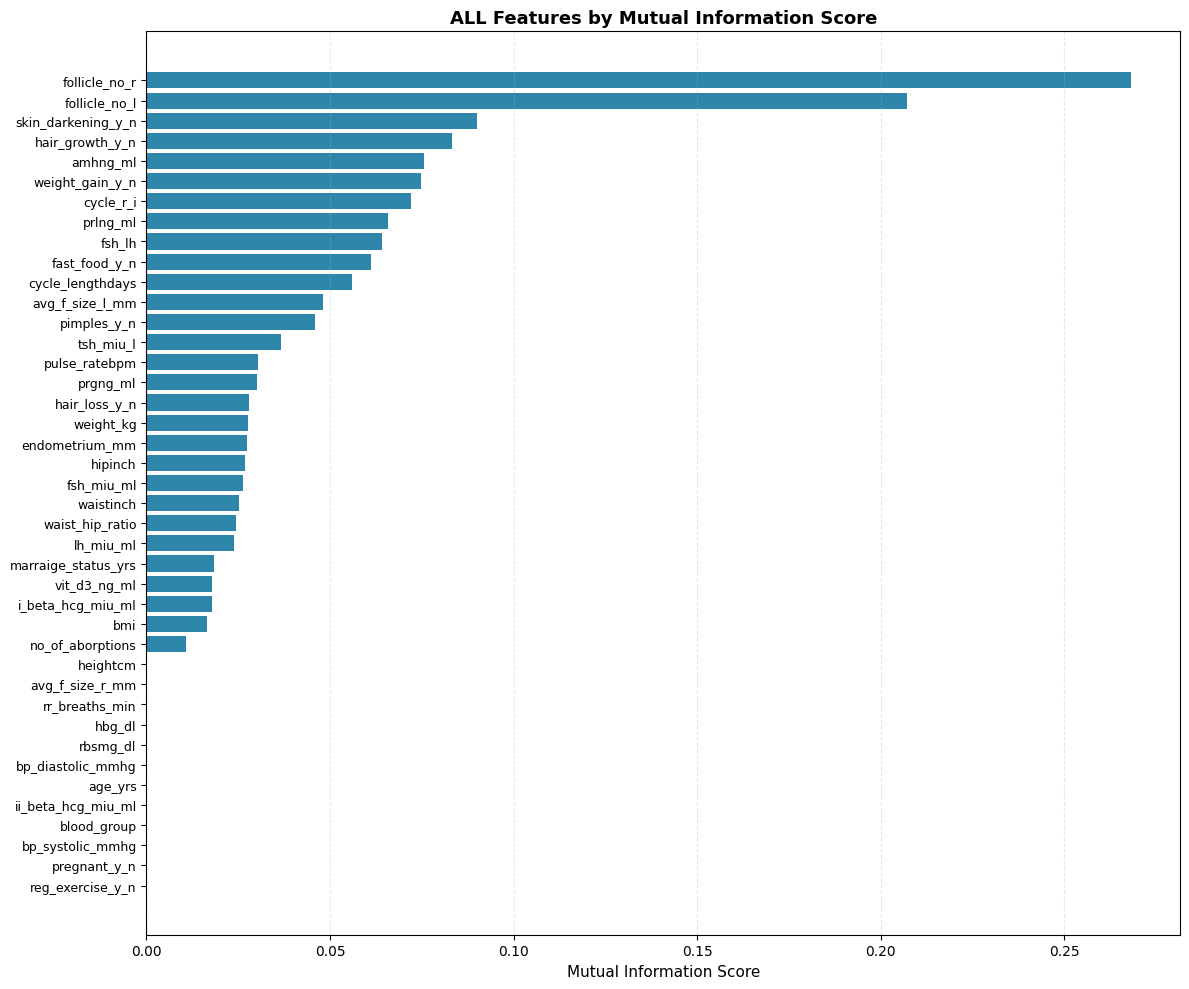


Total features: 41
Features with MI score = 0: 12
Features with MI score > 0: 29


In [32]:
# Visualize ALL features with uniform colors (0 features grayed out)
fig, ax = plt.subplots(figsize=(12, 10))

# Sort by MI score (descending) for better visualization
mi_sorted = mi_df.sort_values('MI_Score', ascending=True)

# Create colors: gray for 0 scores, uniform color for non-zero
colors = ['#CCCCCC' if score == 0 else '#2E86AB' for score in mi_sorted['MI_Score']]

ax.barh(range(len(mi_sorted)), mi_sorted['MI_Score'], color=colors)
ax.set_yticks(range(len(mi_sorted)))
ax.set_yticklabels(mi_sorted['Feature'], fontsize=9)
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('ALL Features by Mutual Information Score', fontsize=13, fontweight='bold')

# Add a light grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nTotal features: {len(mi_df)}")
print(f"Features with MI score = 0: {(mi_df['MI_Score'] == 0).sum()}")
print(f"Features with MI score > 0: {(mi_df['MI_Score'] > 0).sum()}")

In [33]:
# Use Logistic Regression with L1 (LASSO) penalty to find minimal feature set
print("LASSO Feature Selection (L1-regularized Logistic Regression):")
print("=" * 60)

# Try different regularization strengths
alphas = [0.1, 0.01, 0.001, 0.0001]
lasso_results = {}

for alpha in alphas:
    log_reg = LogisticRegression(penalty='l1', C=1/alpha, solver='liblinear', max_iter=1000, random_state=42)
    log_reg.fit(X_scaled, y)
    
    # Get non-zero coefficients
    coef_df = pd.DataFrame({
        'Feature': all_features,
        'Coefficient': log_reg.coef_[0]
    })
    non_zero = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
    
    lasso_results[alpha] = non_zero
    
    print(f"\nC={1/alpha} (alpha={alpha}): {len(non_zero)} non-zero features")
    print(non_zero.to_string(index=False))

# Select the best LASSO model (using C=0.01, alpha=0.01)
best_lasso = LogisticRegression(penalty='l1', C=0.01, solver='liblinear', max_iter=1000, random_state=42)
best_lasso.fit(X_scaled, y)
lasso_mask = best_lasso.coef_[0] != 0
lasso_features = [f for i, f in enumerate(all_features) if lasso_mask[i]]

print(f"\n✅ LASSO Selected Features ({len(lasso_features)} features):")
print(lasso_features)

LASSO Feature Selection (L1-regularized Logistic Regression):

C=10.0 (alpha=0.1): 39 non-zero features
            Feature  Coefficient
      follicle_no_r     1.918370
          lh_miu_ml     1.495833
           prgng_ml    -0.854660
    hair_growth_y_n     0.789284
    weight_gain_y_n     0.730870
      follicle_no_l     0.717372
          cycle_r_i     0.710699
      pulse_ratebpm     0.643822
 skin_darkening_y_n     0.588180
        pimples_y_n     0.455410
marraige_status_yrs    -0.451543
      fast_food_y_n     0.321997
           rbsmg_dl     0.308915
   reg_exercise_y_n     0.295826
          tsh_miu_l     0.248272
   no_of_aborptions    -0.234128
   bp_systolic_mmhg    -0.201353
     endometrium_mm     0.169767
     rr_breaths_min    -0.163565
           amhng_ml     0.149942
       vit_d3_ng_ml     0.120333
    avg_f_size_l_mm     0.120316
             hbg_dl     0.115358
  i_beta_hcg_miu_ml    -0.109350
       pregnant_y_n    -0.107971
  bp_diastolic_mmhg    -0.095762
     

## 3. Low-Cost Clinical Features Analysis

Low-Cost Clinical Features Analysis:
Selected features: ['bmi', 'cycle_r_i', 'cycle_lengthdays', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']

Feature Importance (Low-Cost Only):
           Feature  Coefficient  Abs_Coefficient
skin_darkening_y_n     0.635142         0.635142
   hair_growth_y_n     0.630634         0.630634
         cycle_r_i     0.560206         0.560206
   weight_gain_y_n     0.547236         0.547236
       pimples_y_n     0.409305         0.409305
     fast_food_y_n     0.355834         0.355834
  cycle_lengthdays    -0.255045         0.255045
  reg_exercise_y_n     0.144870         0.144870
               bmi    -0.096328         0.096328
 bp_diastolic_mmhg    -0.095730         0.095730
     hair_loss_y_n    -0.047556         0.047556
  bp_systolic_mmhg    -0.012298         0.012298

Cross-validated ROC-AUC (Low-Cost Features): 0.8727 (+/- 0

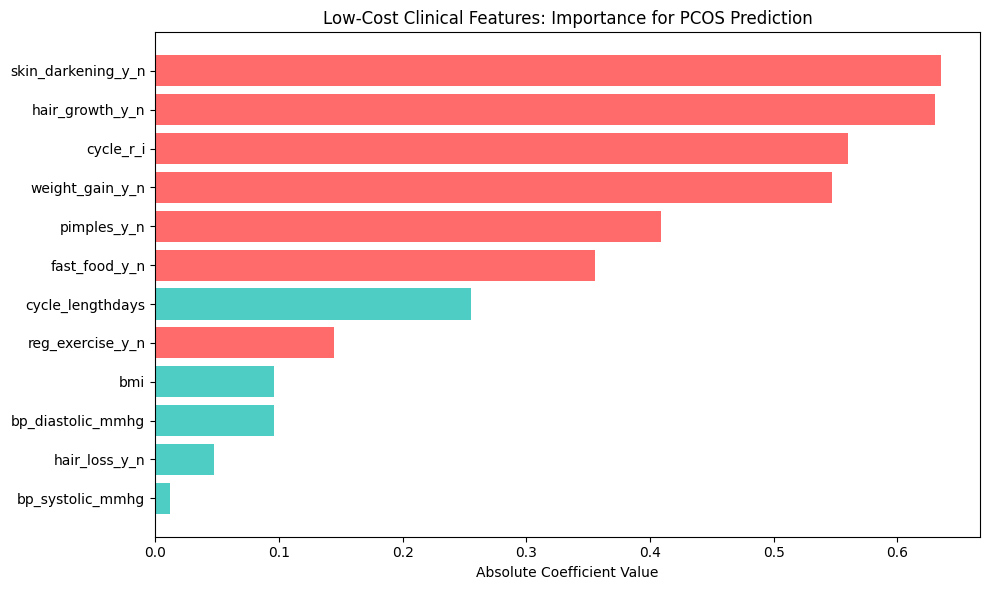

In [34]:
# Low-cost clinical features: BMI, cycle length, symptoms, blood pressure
low_cost_features = ['bmi', 'cycle_r_i','cycle_lengthdays', 'weight_gain_y_n', 'hair_growth_y_n',
                     'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n',
                     'fast_food_y_n', 'reg_exercise_y_n', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']

# Filter to only features present in dataset
low_cost_features = [f for f in low_cost_features if f in all_features]

X_low_cost = X[low_cost_features].fillna(X[low_cost_features].mean())
X_low_cost_scaled = scaler.fit_transform(X_low_cost)

print("Low-Cost Clinical Features Analysis:")
print("=" * 60)
print(f"Selected features: {low_cost_features}\n")

# Train logistic regression on low-cost features
log_reg_low_cost = LogisticRegression(max_iter=1000, random_state=42)
log_reg_low_cost.fit(X_low_cost_scaled, y)

# Calculate feature importance (coefficients)
coef_low_cost = pd.DataFrame({
    'Feature': low_cost_features,
    'Coefficient': log_reg_low_cost.coef_[0],
    'Abs_Coefficient': np.abs(log_reg_low_cost.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (Low-Cost Only):")
print(coef_low_cost[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

# Cross-validated performance
cv_scores_low_cost = cross_val_score(log_reg_low_cost, X_low_cost_scaled, y, cv=5, scoring='roc_auc')
print(f"\nCross-validated ROC-AUC (Low-Cost Features): {cv_scores_low_cost.mean():.4f} (+/- {cv_scores_low_cost.std():.4f})")

# Compare to using all features
log_reg_all = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_all = cross_val_score(log_reg_all, X_scaled, y, cv=5, scoring='roc_auc')
print(f"Cross-validated ROC-AUC (All Features): {cv_scores_all.mean():.4f} (+/- {cv_scores_all.std():.4f})")

# Visualize low-cost feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(coef_low_cost)), coef_low_cost['Abs_Coefficient'], 
        color=['#FF6B6B' if c > 0 else '#4ECDC4' for c in coef_low_cost['Coefficient']])
ax.set_yticks(range(len(coef_low_cost)))
ax.set_yticklabels(coef_low_cost['Feature'])
ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Low-Cost Clinical Features: Importance for PCOS Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Ridge Regression Comparison

Ridge Regression Analysis (L2 Regularization):
Top 15 Features by Ridge Coefficient Magnitude:
            Feature  Ridge_Coefficient  Abs_Ridge_Coef
      follicle_no_r           1.755207        1.755207
    hair_growth_y_n           0.740565        0.740565
      follicle_no_l           0.724163        0.724163
    weight_gain_y_n           0.682201        0.682201
          cycle_r_i           0.663370        0.663370
 skin_darkening_y_n           0.567486        0.567486
      pulse_ratebpm           0.564436        0.564436
           prgng_ml          -0.531454        0.531454
        pimples_y_n           0.434972        0.434972
marraige_status_yrs          -0.396369        0.396369
          lh_miu_ml           0.341762        0.341762
      fast_food_y_n           0.314577        0.314577
   reg_exercise_y_n           0.263329        0.263329
           rbsmg_dl           0.261367        0.261367
          tsh_miu_l           0.223019        0.223019

LASSO vs Ridge Compariso

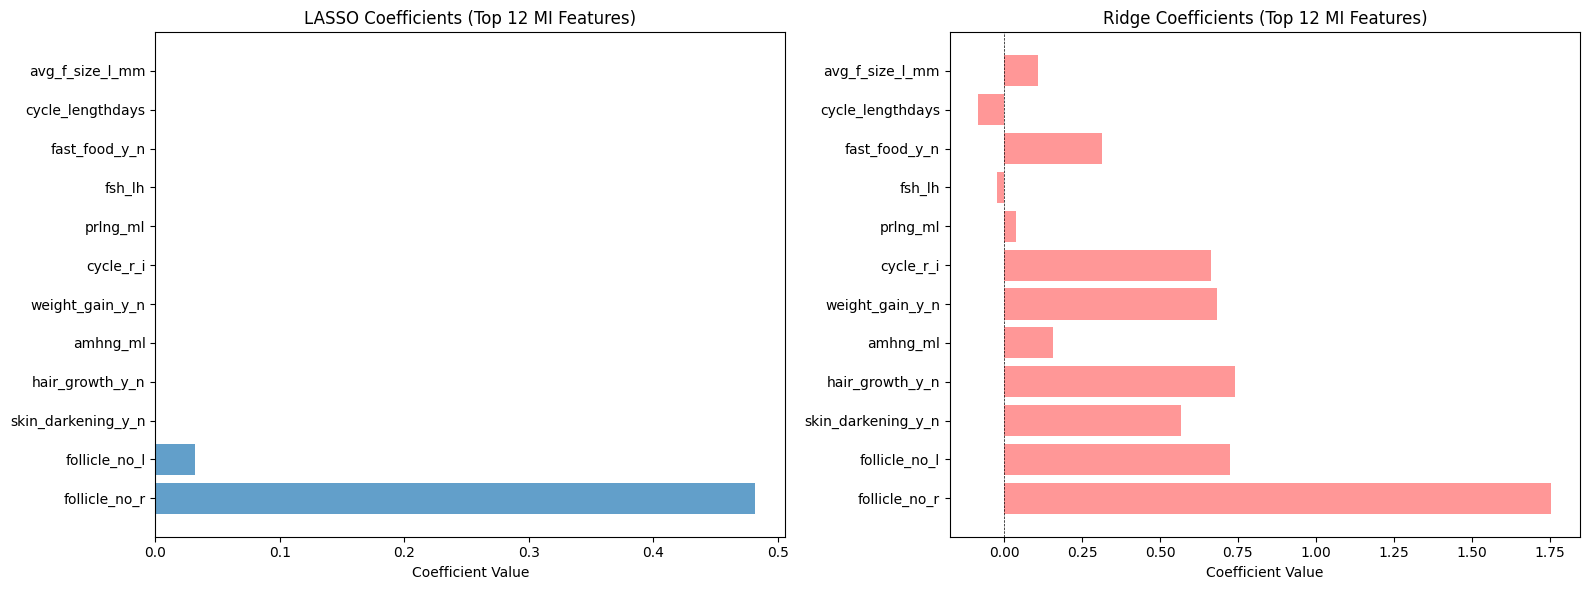

In [35]:
# Ridge Regression comparison (L2 regularization - keeps all features but shrinks coefficients)
print("Ridge Regression Analysis (L2 Regularization):")
print("=" * 60)

ridge_reg = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
ridge_reg.fit(X_scaled, y)

ridge_coef_df = pd.DataFrame({
    'Feature': all_features,
    'Ridge_Coefficient': ridge_reg.coef_[0],
    'Abs_Ridge_Coef': np.abs(ridge_reg.coef_[0])
}).sort_values('Abs_Ridge_Coef', ascending=False)

print("Top 15 Features by Ridge Coefficient Magnitude:")
print(ridge_coef_df.head(15)[['Feature', 'Ridge_Coefficient', 'Abs_Ridge_Coef']].to_string(index=False))

# Compare LASSO vs Ridge
print("\n" + "=" * 60)
print("LASSO vs Ridge Comparison:")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_scores,
    'LASSO_Coef': best_lasso.coef_[0],
    'Ridge_Coef': ridge_reg.coef_[0]
}).sort_values('MI_Score', ascending=False).head(10)

print(comparison_df.to_string(index=False))

# Visualization: LASSO vs Ridge coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top features by MI
top_features_idx = np.argsort(mi_scores)[-12:]
top_features_names = [all_features[i] for i in top_features_idx]
top_lasso_coef = best_lasso.coef_[0][top_features_idx]
top_ridge_coef = ridge_reg.coef_[0][top_features_idx]

ax1.barh(range(len(top_features_names)), top_lasso_coef, alpha=0.7, label='LASSO')
ax1.set_yticks(range(len(top_features_names)))
ax1.set_yticklabels(top_features_names)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('LASSO Coefficients (Top 12 MI Features)')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax1.invert_yaxis()

ax2.barh(range(len(top_features_names)), top_ridge_coef, alpha=0.7, label='Ridge', color='#FF6B6B')
ax2.set_yticks(range(len(top_features_names)))
ax2.set_yticklabels(top_features_names)
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Ridge Coefficients (Top 12 MI Features)')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Summary & Recommendations

### Key Findings:

1. **Mutual Information Scores** - Ranked all features by their predictive power for PCOS
   - Top performers: Follicle counts, AMH, FSH/LH ratio (consistent with EDA findings)
   - Low performers: Some symptoms and physical measurements

2. **LASSO Minimal Feature Set** - Uses L1 regularization to eliminate weak features
   - Produces sparse models with fewer, strongest predictors
   - Trade-off: Simpler model but may lose some predictive power

3. **Low-Cost Clinical Features** - Evaluated affordable, accessible predictors
   - BMI, cycle length, and visible symptoms alone show reasonable predictive power
   - Performance gap compared to full feature set indicates cost-benefit decision needed

4. **Ridge vs LASSO Comparison**:
   - **LASSO**: Feature elimination (better for interpretability)
   - **Ridge**: Feature shrinkage (better for stability, uses all features)
   - Ridge typically performs better in cross-validation when multicollinearity exists

## 5. Fast Food / PCOS Association — BMI Confounding Analysis

Fast food consumption appears in the SHAP minimal feature set, but the report flags it as
potentially acting as a proxy for BMI or broader metabolic dysfunction rather than having
an independent relationship with PCOS.

This section runs logistic regressions to test whether the fast food / PCOS association
persists after controlling for BMI.

Addresses report Section 4.2: *'Controlling for BMI in a regression framework is necessary
to determine whether this association persists after accounting for confounding.'*

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_data.csv')
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')
df = df.fillna(df.median(numeric_only=True))

y = df['pcos_y_n']

# Descriptive: fast food rate by PCOS status
fast_food_by_pcos = df.groupby('pcos_y_n')['fast_food_y_n'].agg(['mean', 'sum', 'count'])
fast_food_by_pcos.index = ['No PCOS', 'PCOS']
fast_food_by_pcos.columns = ['Fast Food Rate', 'Count with Fast Food', 'Total']
print('Fast food consumption by PCOS status:')
print(fast_food_by_pcos.to_string())

# Chi-square test for fast_food vs PCOS
from scipy.stats import chi2_contingency
ct = pd.crosstab(df['fast_food_y_n'], df['pcos_y_n'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'\nChi-square test: χ²={chi2:.4f}, p={p:.4f}, df={dof}')
print(f'Fast food ~ PCOS association: {"significant" if p < 0.05 else "not significant"} (p={p:.4f})')

Fast food consumption by PCOS status:
         Fast Food Rate  Count with Fast Food  Total
No PCOS        0.381868                   139    364
PCOS           0.785311                   139    177

Chi-square test: χ²=75.9886, p=0.0000, df=1
Fast food ~ PCOS association: significant (p=0.0000)


In [37]:
# Model 1: fast_food only
X1 = sm.add_constant(df[['fast_food_y_n']])
model1 = sm.Logit(y, X1).fit(disp=0)

# Model 2: fast_food + BMI (controlling for BMI)
X2 = sm.add_constant(df[['fast_food_y_n', 'bmi']])
model2 = sm.Logit(y, X2).fit(disp=0)

# Model 3: fast_food + BMI + weight_gain (broader metabolic control)
X3 = sm.add_constant(df[['fast_food_y_n', 'bmi', 'weight_gain_y_n']])
model3 = sm.Logit(y, X3).fit(disp=0)

print('=== Model 1: fast_food only ===')
print(model1.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']])

print('\n=== Model 2: fast_food + BMI ===')
print(model2.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']])

print('\n=== Model 3: fast_food + BMI + weight_gain ===')
print(model3.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']])

=== Model 1: fast_food only ===
                  Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
const         -1.778514  0.175386 -10.140574  3.649495e-24 -2.122264 -1.434764
fast_food_y_n  1.778514  0.212482   8.370176  5.753204e-17  1.362057  2.194972

=== Model 2: fast_food + BMI ===
                  Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
const         -3.871593  0.646434 -5.989155  2.109340e-09 -5.138581 -2.604606
fast_food_y_n  1.703423  0.214855  7.928262  2.222344e-15  1.282316  2.124530
bmi            0.086911  0.025374  3.425197  6.143538e-04  0.037179  0.136643

=== Model 3: fast_food + BMI + weight_gain ===
                    Coef.  Std.Err.         z         P>|z|    [0.025  \
const           -2.132010  0.706112 -3.019366  2.533044e-03 -3.515963   
fast_food_y_n    1.331754  0.228184  5.836310  5.336970e-09  0.884521   
bmi             -0.004884  0.030005 -0.162768  8.707009e-01 -0.063693   
weight_gain_y_n  1.646954  0.246113  6.691868

In [38]:
# Odds Ratio summary table
def odds_ratio_table(model, name):
    coefs = model.params
    conf  = model.conf_int()
    pvals = model.pvalues
    df_out = pd.DataFrame({
        'Model':     name,
        'Variable':  coefs.index,
        'OR':        np.exp(coefs).round(3),
        'OR 95% CI': [f"[{np.exp(conf.loc[v, 0]):.3f}, {np.exp(conf.loc[v, 1]):.3f}]"
                      for v in coefs.index],
        'p-value':   pvals.round(4),
        'Sig':       ['*' if p < 0.05 else 'ns' for p in pvals]
    })
    return df_out[df_out['Variable'] != 'const']

or_table = pd.concat([
    odds_ratio_table(model1, 'Unadjusted'),
    odds_ratio_table(model2, '+ BMI'),
    odds_ratio_table(model3, '+ BMI + Weight Gain'),
], ignore_index=True)

print('Odds Ratio Summary:')
print(or_table.to_string(index=False))
or_table.to_csv('../data/processed/fastfood_bmi_confounding.csv', index=False)
print('\nSaved to data/processed/fastfood_bmi_confounding.csv')

Odds Ratio Summary:
              Model        Variable    OR      OR 95% CI  p-value Sig
         Unadjusted   fast_food_y_n 5.921 [3.904, 8.980]   0.0000   *
              + BMI   fast_food_y_n 5.493 [3.605, 8.369]   0.0000   *
              + BMI             bmi 1.091 [1.038, 1.146]   0.0006   *
+ BMI + Weight Gain   fast_food_y_n 3.788 [2.422, 5.924]   0.0000   *
+ BMI + Weight Gain             bmi 0.995 [0.938, 1.055]   0.8707  ns
+ BMI + Weight Gain weight_gain_y_n 5.191 [3.205, 8.409]   0.0000   *

Saved to data/processed/fastfood_bmi_confounding.csv


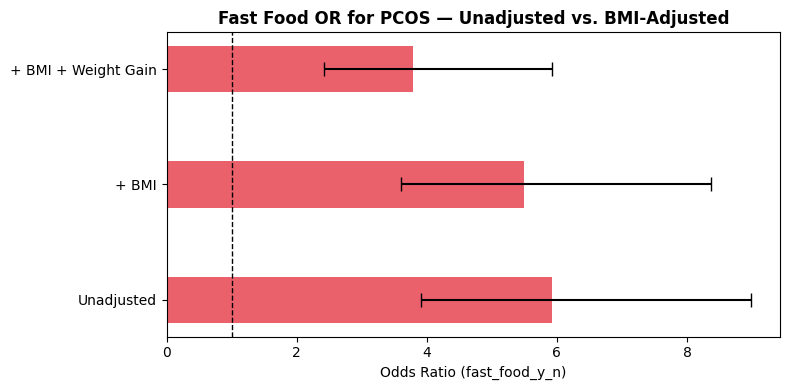

Saved to data/processed/fastfood_confounding_plot.png

--- Interpretation ---
Unadjusted               : OR=5.921 [3.904, 8.980]  -> significant (p=0.0000)
+ BMI                    : OR=5.493 [3.605, 8.369]  -> significant (p=0.0000)
+ BMI + Weight Gain      : OR=3.788 [2.422, 5.924]  -> significant (p=0.0000)


In [39]:
# Visualise: fast_food OR across the three models
ff_ors = or_table[or_table['Variable'] == 'fast_food_y_n'].copy()
ff_ors['Lower'] = ff_ors['OR 95% CI'].str.extract(r'\[(.+),').astype(float)
ff_ors['Upper'] = ff_ors['OR 95% CI'].str.extract(r', (.+)\]').astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(ff_ors))
colors = ['#E63946' if sig == '*' else '#6c757d' for sig in ff_ors['Sig']]

ax.barh(y_pos, ff_ors['OR'], xerr=[
    ff_ors['OR'] - ff_ors['Lower'],
    ff_ors['Upper'] - ff_ors['OR']
], height=0.4, color=colors, alpha=0.8, capsize=5)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(ff_ors['Model'])
ax.set_xlabel('Odds Ratio (fast_food_y_n)')
ax.set_title('Fast Food OR for PCOS — Unadjusted vs. BMI-Adjusted', fontweight='bold')
ax.annotate('OR=1: no effect', xy=(1.0, -0.5), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../data/processed/fastfood_confounding_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/fastfood_confounding_plot.png')

# Interpretation
print('\n--- Interpretation ---')
for _, row in ff_ors.iterrows():
    sig_str = 'significant' if row['Sig'] == '*' else 'NOT significant'
    print(f"{row['Model']:25s}: OR={row['OR']:.3f} {row['OR 95% CI']}  -> {sig_str} (p={row['p-value']:.4f})")